<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

randomstate = 23

In [23]:
# Memuat dataset
df = pd.read_csv('https://raw.githubusercontent.com/febbisena/DataMining/refs/heads/main/Raisin_Dataset.csv')

# Menampilkan dataframe
df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni


In [24]:
# Mengecek ukuran dataset (baris, kolom)
df.shape

(900, 8)

In [25]:
# Menampilkan informasi detail dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [26]:
# Mengecek jumlah nilai yang kosong (missing values) di setiap kolom
df.isna().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [27]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [28]:
# Menampilkan 5 data terakhir dari fitur (X)
x.tail ()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862


In [29]:
# Menampilkan 5 data terakhir dari target (y)
y.tail ()

,Class
895,Besni
896,Besni
897,Besni
898,Besni
899,Besni


In [30]:
print (y.value_counts())

Class
Kecimen    450
Besni      450
Name: count, dtype: int64


In [31]:
# Membagi data menjadi Training Set dan Test Set
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.25,random_state=randomstate)

print("Data train : ", len(X_train))
print("Data test  : ", len(X_test))

Data train :  675
Data test  :  225


In [32]:
# Membuat dan melatih model Decision Tree
model = DecisionTreeClassifier(criterion='entropy',random_state=randomstate)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=23)

In [33]:
# Melakukan prediksi menggunakan data test
y_pred = model.predict(X_test)

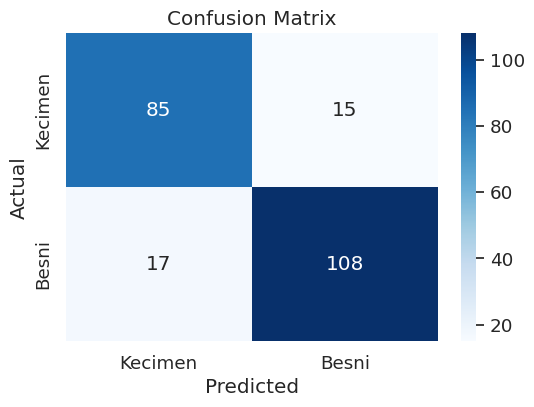

In [34]:
# Mendapatkan nama kelas yang unik untuk label visualisasi
class_names = y.unique()

# Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.set(font_scale=1.2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
# Menampilkan Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(y_test, y_pred,
                                     target_names=class_names, digits=4)
print("Classification Report :\n", class_report)

Classification Report :
               precision    recall  f1-score   support

     Kecimen     0.8333    0.8500    0.8416       100
       Besni     0.8780    0.8640    0.8710       125

    accuracy                         0.8578       225
   macro avg     0.8557    0.8570    0.8563       225
weighted avg     0.8582    0.8578    0.8579       225



In [36]:
# Menampilkan Skor Akurasi Akhir
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%")

Accuracy Score: 85.78%


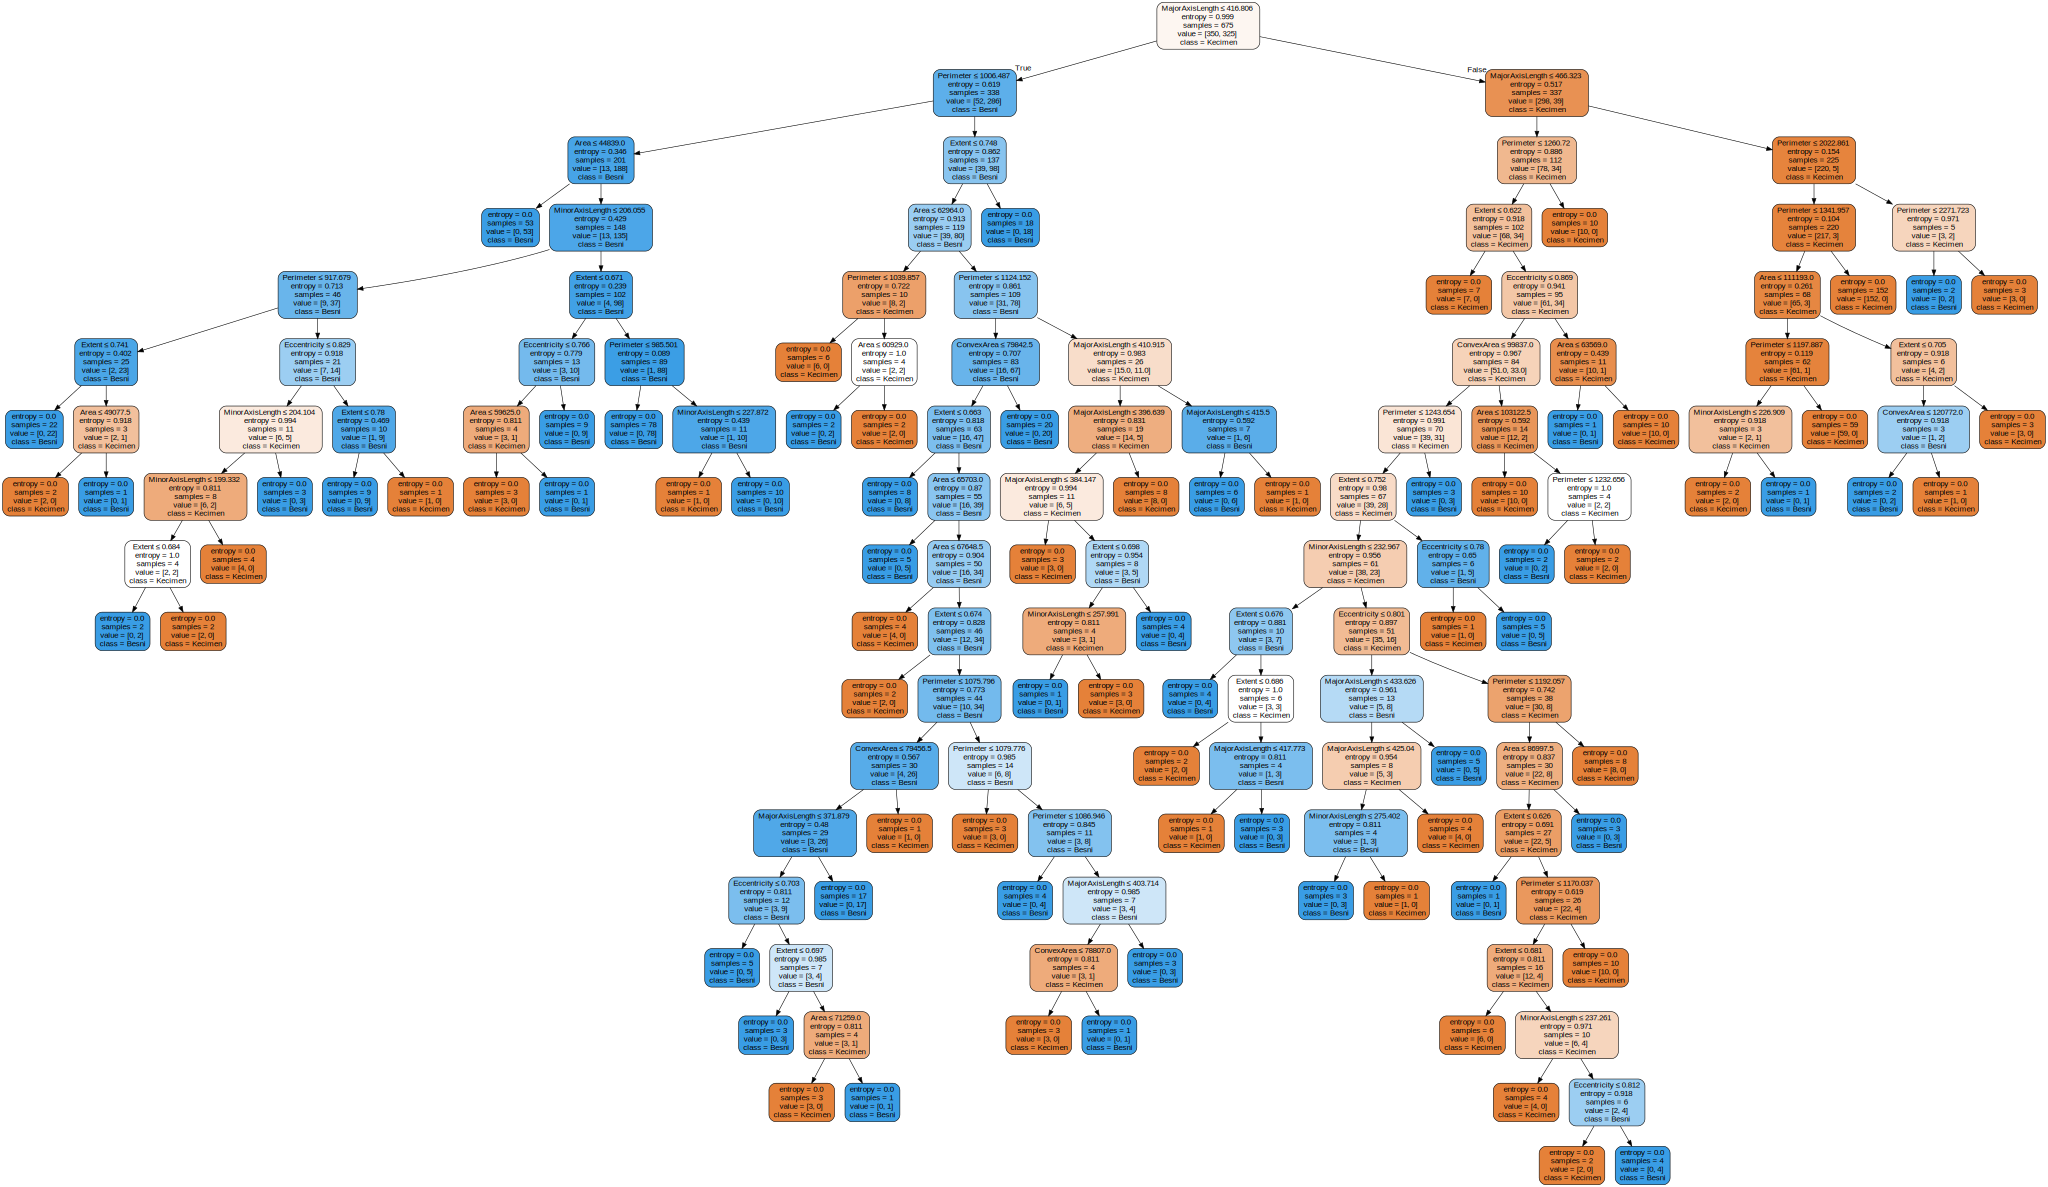

In [38]:
# Menyiapkan nama fitur dan nama kelas untuk visualisasi pohon
feature_names = x.columns.tolist()
class_names = y.unique().tolist()

# Mengekspor struktur pohon ke format DOT
dot_data = export_graphviz(model, out_file=None,
                           feature_names=feature_names,
                           class_names=class_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Membuat grafik dari data DOT dan menyimpannya sebagai file PNG
graph = graphviz.Source(dot_data)
graph.render(filename='decision_tree', format='png', cleanup=True)
graph # Ini akan menampilkan pohon langsung di notebook

In [40]:
# --- Membuat Tabel Perbandingan ---

# Membuat DataFrame baru untuk data pengujian
test_df = pd.DataFrame(X_test, columns=x.columns)

# Menambahkan kolom kelas aktual dan kelas hasil prediksi
test_df['Actual Class'] = y_test.values
test_df['Predicted Class'] = y_pred

# Menampilkan 5 baris pertama tabel perbandingan
test_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Actual Class,Predicted Class
774,76624,473.965993,207.736989,0.898831,80356,0.661008,1205.819,Besni,Besni
737,48007,302.611047,209.116084,0.722817,50679,0.677051,889.743,Besni,Kecimen
753,79057,436.390047,236.895393,0.839828,82642,0.654597,1148.146,Besni,Besni
890,85646,469.774755,238.539384,0.861490,92673,0.681044,1226.892,Besni,Besni
428,48093,329.935742,187.041722,0.823784,49367,0.745108,858.386,Kecimen,Besni


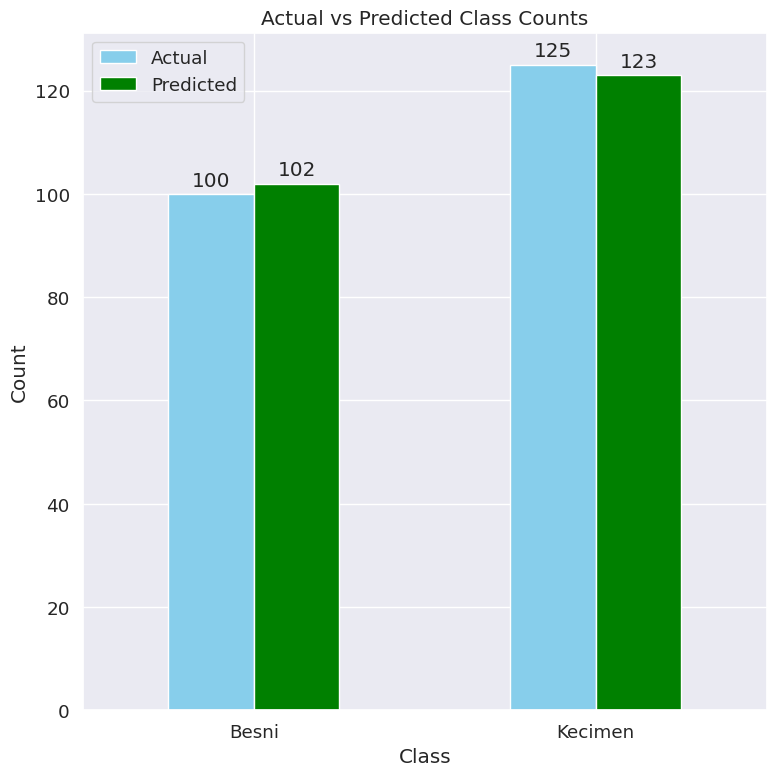

In [41]:
# Mengelompokkan data untuk membandingkan jumlah total aktual vs prediksi
comparison_df = test_df.groupby('Actual Class').size().to_frame('Actual')
comparison_df['Predicted'] = test_df.groupby('Predicted Class').size()

# Menangani nilai kosong jika ada kelas yang tidak terprediksi sama sekali
comparison_df.fillna(0, inplace=True)
comparison_df = comparison_df.astype(int)

# Menampilkan grafik batang perbandingan
ax = comparison_df.plot(kind='bar', figsize=(8, 8), color=['skyblue', 'green'])

ax.bar_label(ax.containers[0], fmt='%d', padding=3)
ax.bar_label(ax.containers[1], fmt='%d', padding=3)

plt.title('Actual vs Predicted Class Counts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
test_df.to_excel('CP45_Data Test & Prediction.xlsx', index=False)